# Estimate Mechanistic Model

A second order model is for the heater/sensor combination is given by

$$
\begin{align}
C^H_p\frac{dT_{H,1}}{dt} & = U_a(T_{amb} - T_{H,1}) + U_b(T_{S,1} - T_{H,1}) + P_1u_1\\
C^S_p\frac{dT_{S,1}}{dt} & = U_b(T_{H,1} - T_{S,1}) 
\end{align}
$$

where $T_{H,1}$ is the heater temperature, $T_{S,1}$ is the sensor temperature, and $U_b$ is the heat transfer coefficient between the heater and sensor. 

<Axes: xlabel='Time', ylabel='%'>

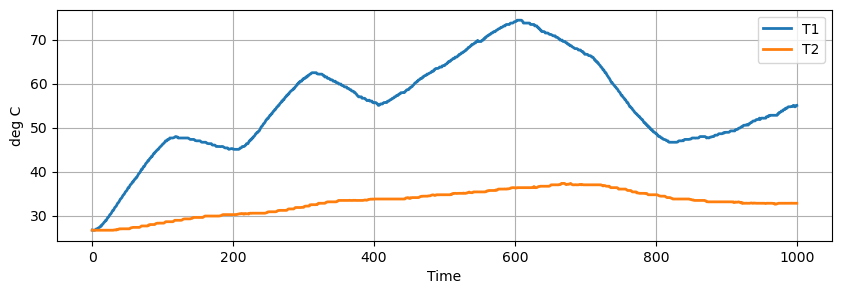

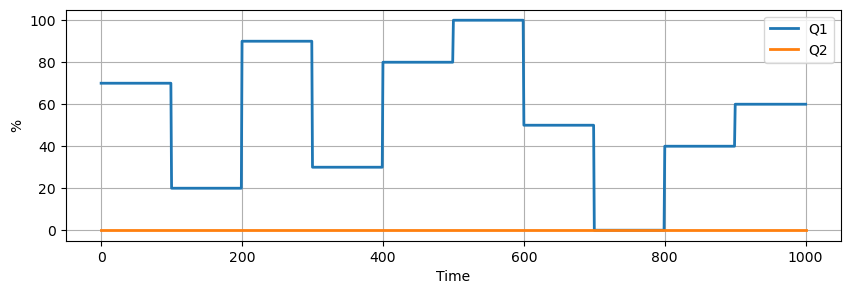

In [1]:
# Load and plot data

data_file = "step_tests.csv"

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

data = pd.read_csv(data_file)
data.plot(x = "Time", y=["T1", "T2"], figsize=(10, 3), grid=True, lw=2, ylabel="deg C")
data.plot(x = "Time", y=["Q1", "Q2"], figsize=(10, 3), grid=True, lw=2, ylabel="%")

,Time,TH1,TS1,Q1
0,0.00,21.000000,21.000000,50
1,1.00,21.443586,21.010943,50
2,2.00,21.878602,21.042773,50
3,3.00,22.305457,21.093899,50
4,4.00,22.724735,21.161988,50
...,...,...,...,...
995,996.00,52.220580,50.852274,50
996,997.01,52.279029,50.921111,50
997,998.00,52.335852,50.988077,50
998,999.00,52.392781,51.055210,50


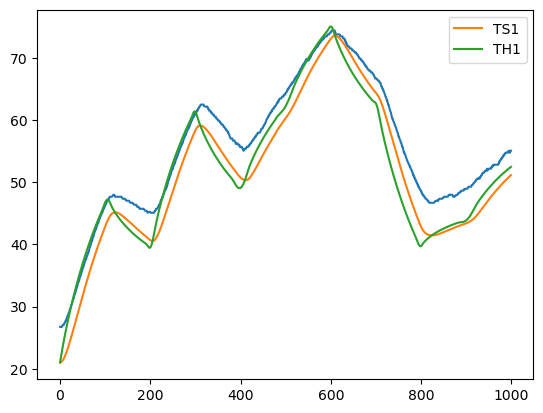

In [12]:
# Implement and test model

# known parameters
T_amb = 21 # deg C
alpha = 0.00016 # watts / (units P1 * percent U1)
P1 = 200 # P1 units
U1 = 50 # steady state value of u1 (percent)
# P2 = 100 # P2 units
# U2 = 0 # steady state value of u1 (percent)

# adjustable parameters
Ua = 0.05 # watts/deg C
Ub = 0.05 # watts/deg C
CpH = 5 # joules/deg C
CpS = 1 # joules/deg C

# extract data from experiment
t_expt = data["Time"]

def u_data(t):
    # This is slow
    return np.interp(t, t_expt, data["Q1"])

def step_tests(t):
    if t < 100:
        return 70
    elif t < 200:
        return 20
    elif t < 300:
        return 90
    elif t < 400:
        return 30
    elif t < 500:
        return 80
    elif t < 600:
        return 100
    elif t < 700: 
        return 50
    elif t < 800:
        return 0
    elif t < 900:
        return 40
    else:
        return 60

def tclab_model2(param):
    # unpack the adjustable parameters
    Ua, Ub, CpH, CpS = param
    
    # model solution
    def deriv(t, y):
        T1H, T1S = y
        dT1H = (-(Ua + Ub)*T1H + Ub*T1S + alpha*P1*step_tests(t) + Ua*T_amb)/CpH
        dT1S = Ub*(T1H - T1S)/CpS
        return [dT1H, dT1S]
    soln = solve_ivp(deriv, [min(t_expt), max(t_expt)], [T_amb, T_amb], t_eval=t_expt)
    
    # create dataframe with predictions
    pred = pd.DataFrame(columns=["Time"])
    pred["Time"] = t_expt
    pred["TH1"] = soln.y[0]
    pred["TS1"] = soln.y[1]
    pred["Q1"] = U1
    
    return pred
pred = tclab_model2([Ua, Ub, CpH, CpS])
ax = data["T1"].plot()
pred[["TS1", "TH1"]].plot(ax=ax)
pred

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.1908e+02                                    2.20e+03    
       1              2         5.8627e+02      1.33e+02       1.12e+00       2.61e+04    
       2              3         5.5007e+02      3.62e+01       1.96e-01       1.67e+04    
       3              4         5.1133e+02      3.87e+01       8.92e-02       1.05e+04    
       4              5         5.0459e+02      6.73e+00       3.77e-01       2.50e+02    
       5              7         5.0069e+02      3.91e+00       7.94e-02       4.06e+02    
       6              9         4.9614e+02      4.55e+00       3.96e-02       1.44e+03    
       7             11         4.9144e+02      4.70e+00       2.00e-02       3.99e+03    
       8             18         4.9140e+02      4.72e-02       7.46e-06       3.85e+03    
       9             20         4.9137e+02      2.33e-02       3.81e-06       3.77e+03    

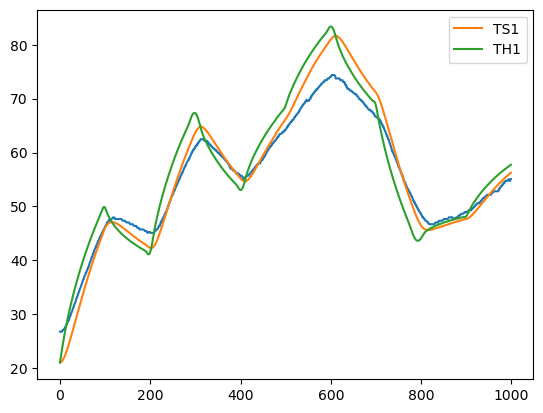

In [13]:
# Regress model

from scipy.optimize import least_squares
import matplotlib.pyplot as plt

def residuals(p):
    pred = tclab_model2(p)
    return pred["TS1"] - data["T1"]

# Next step: multistart initialization

# Set initial point
p0 = [Ua, Ub, CpH, CpS]

# Set bounds (non-negative)
bnds = ([0.0, 0.0, 0.0, 0.0], [np.inf, np.inf, np.inf, np.inf])

# Perform least squares nonlinear regression
nl_results = least_squares(residuals, p0, bounds=bnds, method='trf', verbose=2, loss="arctan")
p = nl_results.x

# extract and print values
Ua, Ub, CpH, CpS = nl_results.x

# Plot fitted model
pred = tclab_model2(nl_results.x)
ax = data["T1"].plot(grid=True)
pred[["TS1", "TH1"]].plot(ax=ax)
plt.show()

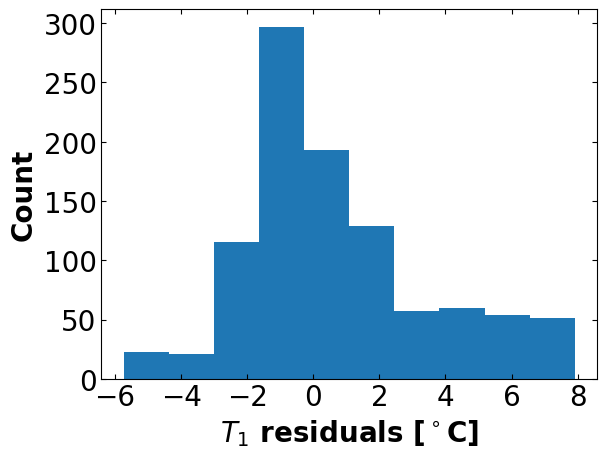

Estimated standard deviation of residuals: 2.935221871778186 deg C

Covariance of p = [Ua, Ub, CpH, CpS]
[[ 1.11610177e-07 -2.21377340e-07 -2.04524651e-05  4.55998632e-06]
 [-2.21377340e-07  6.06737781e-05 -3.50518586e-03  3.20737816e-03]
 [-2.04524651e-05 -3.50518586e-03  3.68512987e-01 -2.57279107e-01]
 [ 4.55998632e-06  3.20737816e-03 -2.57279107e-01  2.00862003e-01]]


In [14]:
# Plot histogram of residuals

### Plots residuals
r = residuals(p).to_numpy()

# define font size
fs = 20

# plot data
plt.hist(r)
plt.xlabel("$T_1$ residuals [$^\circ{}$C]",fontsize=fs,fontweight = 'bold')
plt.ylabel("Count",fontsize=fs,fontweight = 'bold')

# define tick size
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.tick_params(direction="in",top=True, right=True)

# finish plot
plt.show()

# Estimate covariance and correlation of fitted parameters

#Estimate covariance of residuals
var_residuals = r.T@r / (len(r) - len(p))
print("Estimated standard deviation of residuals:",np.sqrt(var_residuals),"deg C")

# Estimate covariance of fitted parameters
cov_p = var_residuals * np.linalg.inv(nl_results.jac.T @ nl_results.jac)

### END SOLUTION

print("\nCovariance of p = [Ua, Ub, CpH, CpS]")
print(cov_p)


Text(0, 0.5, 'Residual Derivative [$^\\circ{}$C/s]')

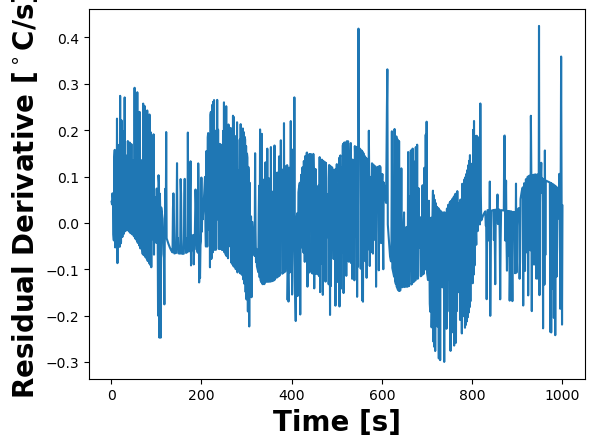

In [17]:
dresid_dt = np.diff(r) / np.diff(t_expt)

# plot data
plt.plot(t_expt[1:],dresid_dt)
plt.xlabel("Time [s]",fontsize=fs,fontweight = 'bold')
plt.ylabel("Residual Derivative [$^\circ{}$C/s]",fontsize=fs,fontweight = 'bold')

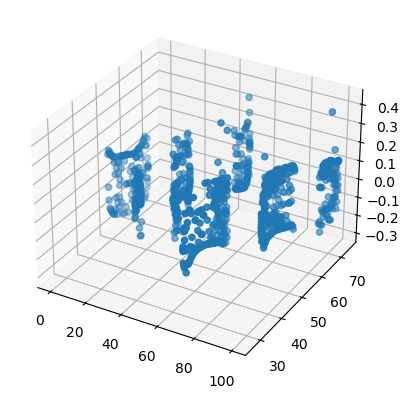

In [21]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(data["Q1"][1:],data["T1"][1:],dresid_dt)

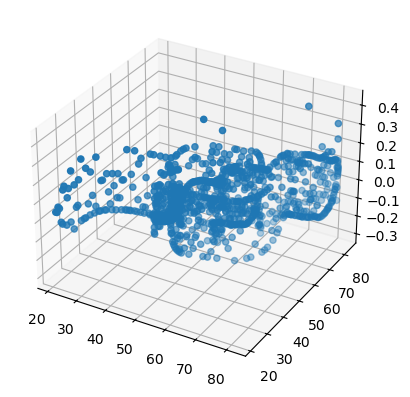

In [23]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(pred["TS1"][1:],pred["TH1"][1:],dresid_dt)

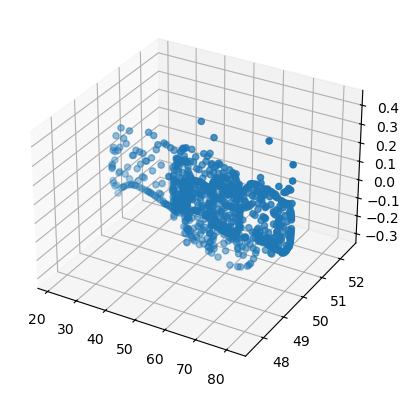

In [24]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(pred["TS1"][1:],pred["Q1"][1:],dresid_dt)

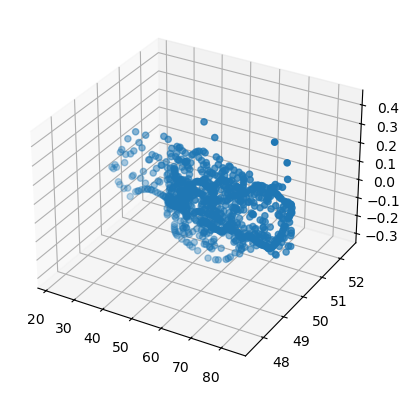

In [25]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(pred["TH1"][1:],pred["Q1"][1:],dresid_dt)